In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
data = pd.read_csv("clustering_data.csv" , low_memory = False)
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')
data = data[(data["Latitude"] != float('NaN')) | (data["Longitude"] != float('NaN'))]

In [4]:
data = data[data["StateName"] == "UTTAR PRADESH"]
data.head()

,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
201,Uttar Pradesh Circle,Kanpur Region,Kanpur HO Division,NDC Kanpur,208001,PO,Non Delivery,KANPUR NAGAR,UTTAR PRADESH,NaN,NaN
277,Uttar Pradesh Circle,Gorakhpur Region,Gorakhpur Division,NDC Gorakhpur,273001,PO,Non Delivery,GORAKHPUR,UTTAR PRADESH,26.760600,83.373200
1172,Uttar Pradesh Circle,Lucknow HQ Region,Ghaziabad Division,NDC Ghaziabad,201001,PO,Non Delivery,GHAZIABAD,UTTAR PRADESH,28.655600,77.427700
1281,Uttar Pradesh Circle,Agra Region,Agra Division,NDC Agra,282001,PO,Non Delivery,AGRA,UTTAR PRADESH,27.165185,78.011902
2480,Uttar Pradesh Circle,Allahabad Region,Allahabad Division,NTPC Kohdar Meja SO,212308,PO,Delivery,PRAYAGRAJ,UTTAR PRADESH,25.141700,81.984600


In [5]:
data = data[(data["Latitude"] > 23.52 ) & (data["Latitude"] < 31.28) & (data["Longitude"] < 84.39) & (data["Longitude"] > 77.03)]

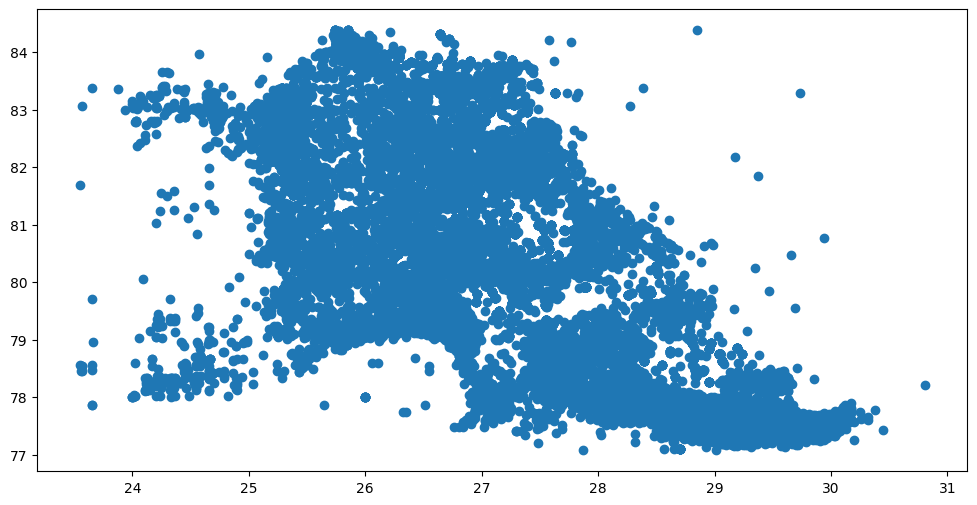

In [6]:
plt.figure(figsize = (12,6))
plt.scatter(data["Latitude"] , data["Longitude"])
plt.show()

In [7]:
def distance(x , y):
    dist = x**2 + y**2
    dist = np.sqrt(dist)
    dist = np.sum(dist)
    return dist

In [8]:
class K_means:
    def __init__(self , data , n_categories , epsilon):
        self.n_categories = n_categories
        self.X = data
        self.cat = np.array([0]*len(self.X))
        self.epsilon = epsilon
    
    def init_cluster_centres(self):
        df = self.X.to_numpy()
        idx = np.random.randint(0, len(df))
        centers = [df[idx].copy()]
    
        for i in range(self.n_categories - 1):
            dists = np.array([
                min(np.dot(df[j] - c, df[j] - c) for c in centers)
                for j in range(len(df))
                ])
            probs = dists / dists.sum()
            idx = np.random.choice(len(df), p=probs)
            centers.append(df[idx].copy())
    
        return np.array(centers)
    def assignment(self, centers , point):
        min_dist = float('inf')
        min_ind = -1 
        for i in range(len(centers)):
            dist = np.dot((centers[i]-point),(centers[i]-point))
            if dist < min_dist:
                min_dist = dist 
                min_ind = i
        return min_ind
    def reassign_centre(self , centers):
        df = self.X
        cat = self.cat
        for i in range(len(centers)):
            indices = cat == i 
            if indices.sum() > 0: 
             centers[i] = np.mean(df[indices], axis=0)
        return centers
    def main(self):
        df = self.X.to_numpy()
        
        centers = self.init_cluster_centres()
        o_centers = np.zeros((self.n_categories , self.X.shape[1]))
        while np.linalg.norm(centers - o_centers) > self.epsilon:
            for i in range(len(df)):
                self.cat[i] = self.assignment(centers , df[i])
            o_centers = centers.copy()
            centers = self.reassign_centre(centers)
        return 
    def predict(self):
        self.main()
        return self.cat    

In [9]:
#HYPERPARAMETERS OF MODEL 
k = 3
epsilon = 0.01

In [10]:
model = K_means(data[["Latitude" , "Longitude"]] , k , epsilon)
predictions = np.array(model.predict())
print(predictions)

[0 1 1 ... 1 1 1]


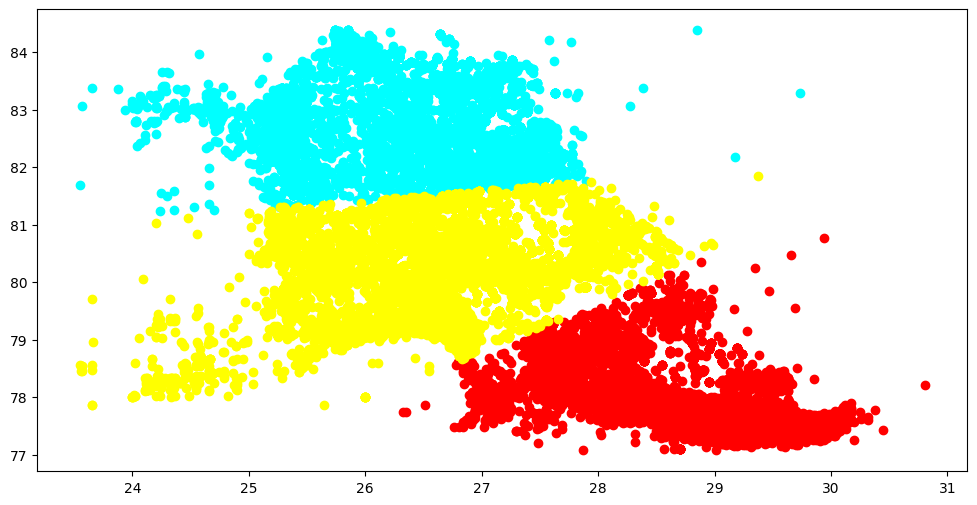

In [12]:
plt.figure(figsize=(12,6))
colors = ["cyan" , "red" , "yellow" , "pink", "cyan"]
labels = ["Cat_1" , "Cat_2" , "Cat_3" , "Cat_4"]

for i in range(k):
        indices = predictions == i
        plt.scatter((data["Latitude"].to_numpy())[indices] , (data["Longitude"].to_numpy())[indices] , c = colors[i] , label = labels[i])
plt.show()
    